In [ ]:
# Portfolio Visualization

This notebook visualizes the main out-of-sample portfolio results generated in the rolling backtest.

The figures include:

- Portfolio wealth paths
- Drawdown dynamics
- Risk–return trade-offs
- Average portfolio allocations
- Sensitivity to transaction costs

Final benchmark figures including passive SPY are generated separately in `06_final_benchmark.ipynb`.

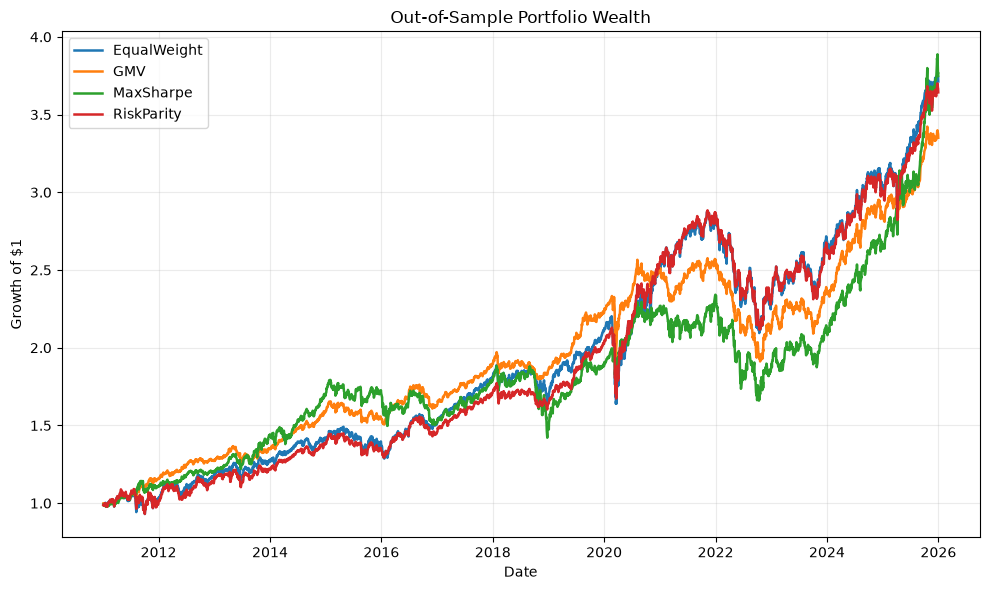

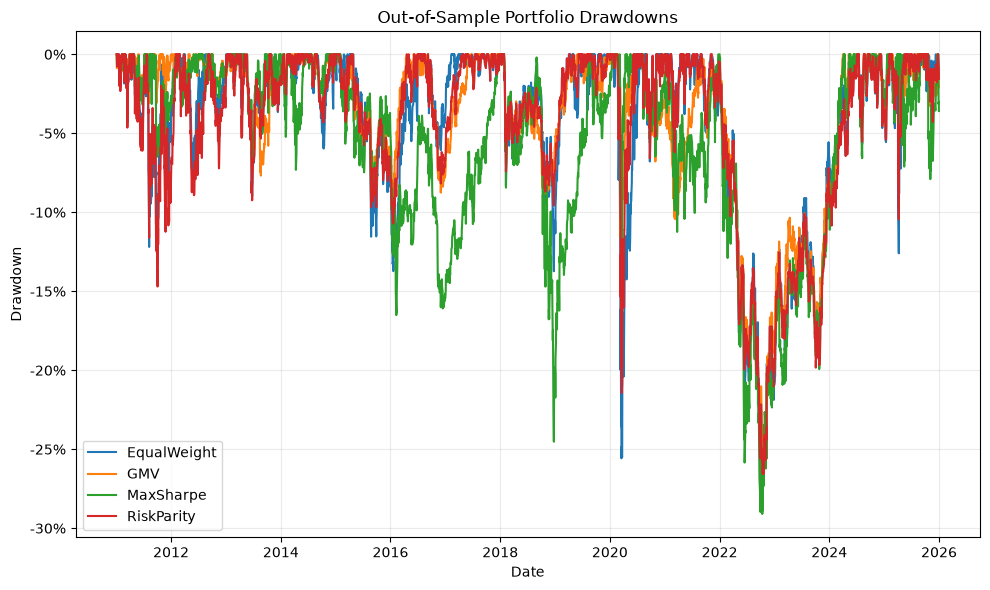

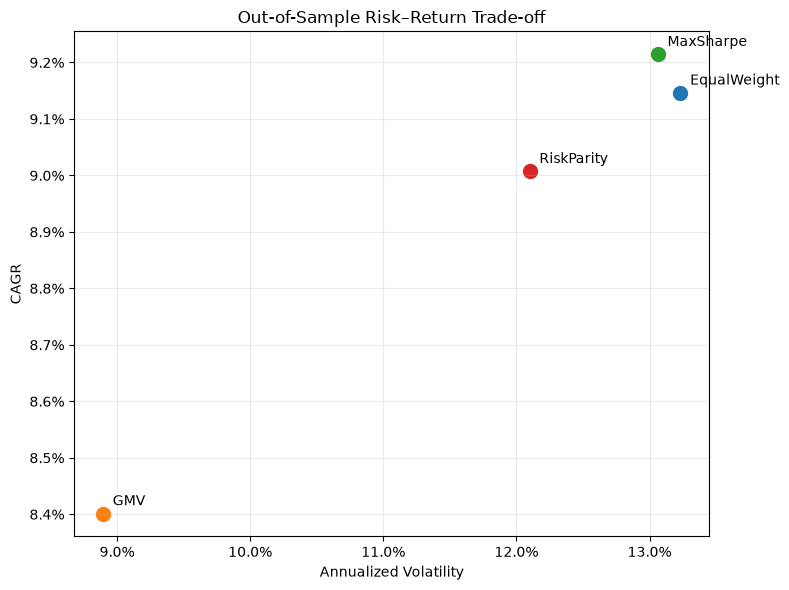

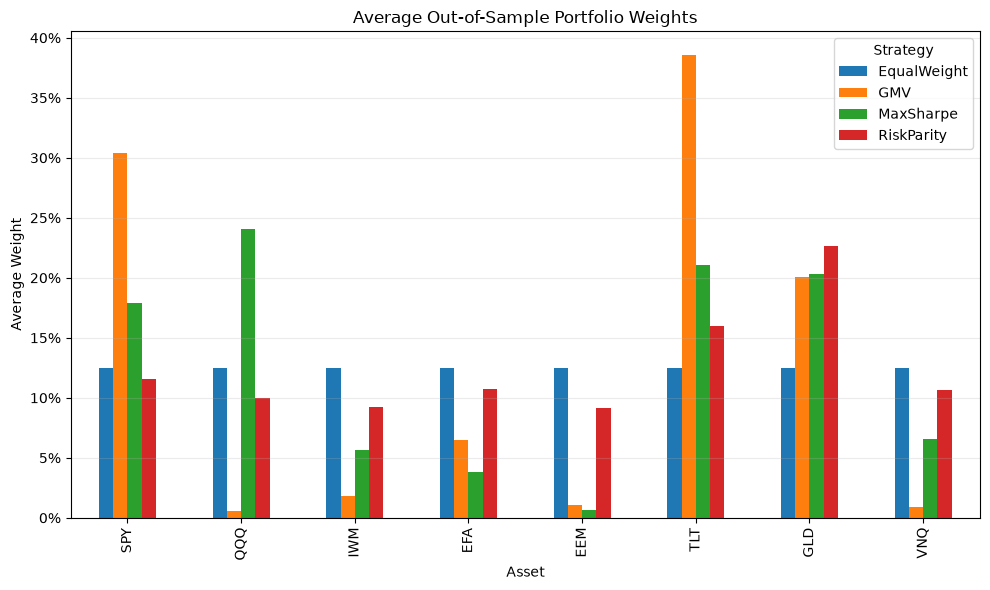

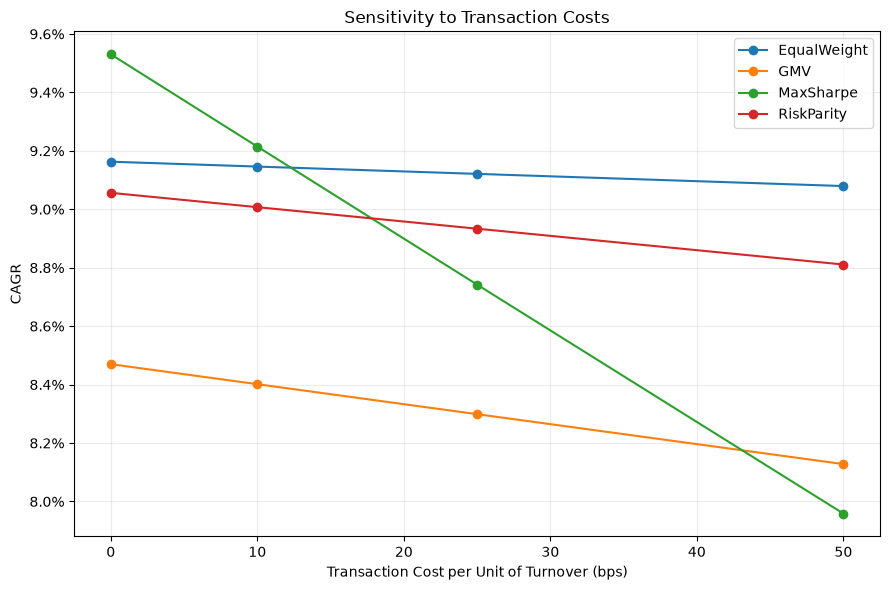

All figures saved to: C:\Projects\quant_portfolio_project\outputs


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../outputs")

strategies = [
    "EqualWeight",
    "GMV",
    "MaxSharpe",
    "RiskParity"
]

# ==========================================
# 1. Load saved backtests
# ==========================================

backtests = {}

for strategy in strategies:
    backtests[strategy] = pd.read_csv(
        output_dir / f"{strategy}_oos_backtest.csv",
        index_col=0,
        parse_dates=True
    )

wealth = pd.DataFrame({
    strategy: backtests[strategy]["Wealth"]
    for strategy in strategies
})


# ==========================================
# 2. Wealth curves
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for strategy in strategies:
    ax.plot(
        wealth.index,
        wealth[strategy],
        label=strategy,
        linewidth=1.8
    )

ax.set_title(
    "Out-of-Sample Portfolio Wealth"
)
ax.set_ylabel(
    "Growth of $1"
)
ax.set_xlabel(
    "Date"
)

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir / "01_oos_wealth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 3. Drawdown curves
# ==========================================

drawdowns = (
    wealth
    / wealth.cummax()
    - 1
)

fig, ax = plt.subplots(figsize=(10, 6))

for strategy in strategies:
    ax.plot(
        drawdowns.index,
        drawdowns[strategy],
        label=strategy,
        linewidth=1.5
    )

ax.set_title(
    "Out-of-Sample Portfolio Drawdowns"
)
ax.set_ylabel(
    "Drawdown"
)
ax.set_xlabel(
    "Date"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.0%}"
    )
)

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir / "02_oos_drawdowns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 4. Risk-return comparison
# ==========================================

metrics = pd.read_csv(
    output_dir / "oos_strategy_metrics.csv",
    index_col=0
)

fig, ax = plt.subplots(figsize=(8, 6))

for strategy in strategies:

    x = metrics.loc[
        strategy,
        "Annualized_Volatility"
    ]

    y = metrics.loc[
        strategy,
        "CAGR"
    ]

    ax.scatter(
        x,
        y,
        s=100
    )

    ax.annotate(
        strategy,
        (x, y),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title(
    "Out-of-Sample Risk–Return Trade-off"
)

ax.set_xlabel(
    "Annualized Volatility"
)

ax.set_ylabel(
    "CAGR"
)

# Use one decimal place so nearby values remain distinguishable
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.1%}"
    )
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.1%}"
    )
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir / "03_risk_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 5. Average portfolio weights
# ==========================================

weights = pd.read_csv(
    output_dir / "average_strategy_weights.csv",
    index_col=0
)

fig, ax = plt.subplots(figsize=(10, 6))

weights.T.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Average Out-of-Sample Portfolio Weights"
)

ax.set_xlabel(
    "Asset"
)

ax.set_ylabel(
    "Average Weight"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.0%}"
    )
)

ax.legend(
    title="Strategy"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

fig.savefig(
    output_dir / "04_average_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 6. Transaction-cost sensitivity
# ==========================================

cost_data = pd.read_csv(
    output_dir
    / "transaction_cost_robustness.csv"
)

cost_order = {
    "0bps": 0,
    "10bps": 10,
    "25bps": 25,
    "50bps": 50
}

cost_data["Cost_bps"] = (
    cost_data["Transaction_Cost"]
    .map(cost_order)
)

fig, ax = plt.subplots(figsize=(9, 6))

for strategy in strategies:

    d = (
        cost_data[
            cost_data["Strategy"]
            == strategy
        ]
        .sort_values("Cost_bps")
    )

    ax.plot(
        d["Cost_bps"],
        d["CAGR"],
        marker="o",
        label=strategy
    )

ax.set_title(
    "Sensitivity to Transaction Costs"
)

ax.set_xlabel(
    "Transaction Cost per Unit of Turnover (bps)"
)

ax.set_ylabel(
    "CAGR"
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.1%}"
    )
)

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir
    / "05_transaction_cost_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "All figures saved to:",
    output_dir.resolve()
)